# Lab 3 — Image Manipulations using OpenCV
### ARTI 404 – Image Processing

**Task 1:** Geometric transformations (resize, rotate 120°, shear)
**Task 2:** Intensity transformations (negative, log transform, power-law / gamma)

The input image (`images/input.jpg`) is the `astronaut` sample image from `scikit-image`
(https://scikit-image.org/docs/stable/auto_examples/data/plot_general.html), saved to disk
so it can be read with `cv2.imread` like any other image.

Image shape: (512, 512, 3)
Image dtype: uint8


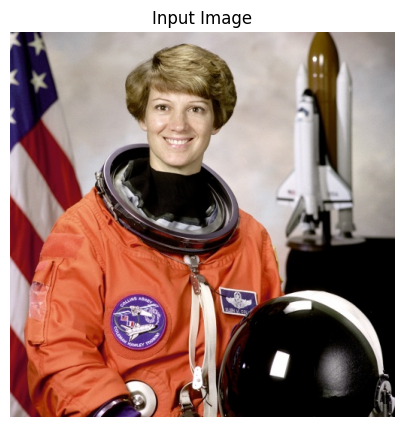

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import skimage as ski
import os

os.makedirs('images', exist_ok=True)

# Get a sample image from scikit-image and save it as our input image
sample = ski.data.astronaut()                       # RGB array
bgr = cv2.cvtColor(sample, cv2.COLOR_RGB2BGR)
cv2.imwrite('images/input.jpg', bgr)

# Step 1: Read the image using OpenCV
img = cv2.imread('images/input.jpg')
print('Image shape:', img.shape)
print('Image dtype:', img.dtype)

def show(img_bgr, title):
    plt.figure(figsize=(5, 5))
    if len(img_bgr.shape) == 2:
        plt.imshow(img_bgr, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

show(img, 'Input Image')

## Task 1 — Geometric Transformations

### 1.1 Increase the size of the image

Original size: (512, 512)
Resized size : (768, 768)


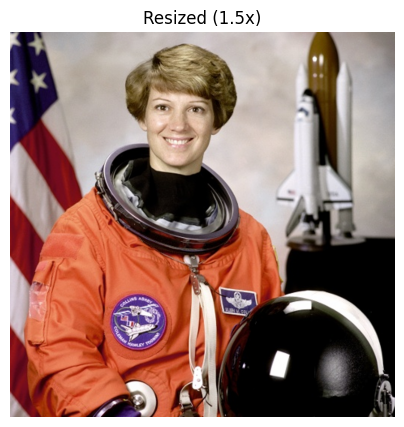

In [2]:
# Scale up the image by 1.5x using bicubic interpolation (better quality for enlarging)
scale_factor = 1.5
resized = cv2.resize(img, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_CUBIC)

print('Original size:', img.shape[:2])
print('Resized size :', resized.shape[:2])

cv2.imwrite('images/task1_resized.jpg', resized)
show(resized, f'Resized ({scale_factor}x)')

### 1.2 Rotate the image by 120 degrees

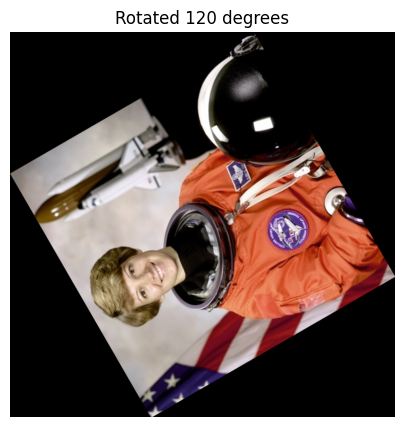

In [3]:
(h, w) = img.shape[:2]
center = (w // 2, h // 2)

angle = 120
M_rotate = cv2.getRotationMatrix2D(center, angle, 1.0)

# Compute new bounding dimensions so the rotated image isn't cropped
cos = np.abs(M_rotate[0, 0])
sin = np.abs(M_rotate[0, 1])
new_w = int((h * sin) + (w * cos))
new_h = int((h * cos) + (w * sin))

# Adjust the rotation matrix to account for translation
M_rotate[0, 2] += (new_w / 2) - center[0]
M_rotate[1, 2] += (new_h / 2) - center[1]

rotated = cv2.warpAffine(img, M_rotate, (new_w, new_h))

cv2.imwrite('images/task1_rotated_120.jpg', rotated)
show(rotated, 'Rotated 120 degrees')

### 1.3 Perform Shear operations over the image

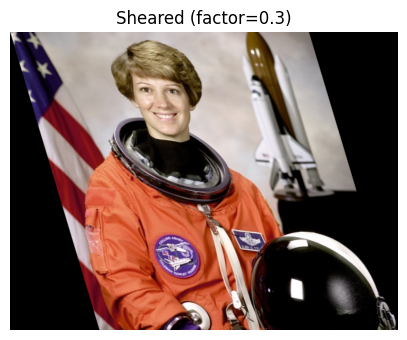

In [4]:
# Shear along the x-axis using an affine transform
shear_factor = 0.3

M_shear = np.float32([[1, shear_factor, 0],
                       [0, 1,           0]])

# Widen the output canvas so the sheared content isn't cut off
new_w = int(w + abs(shear_factor) * h)
sheared = cv2.warpAffine(img, M_shear, (new_w, h))

cv2.imwrite('images/task1_sheared.jpg', sheared)
show(sheared, f'Sheared (factor={shear_factor})')

### Task 1 — Summary

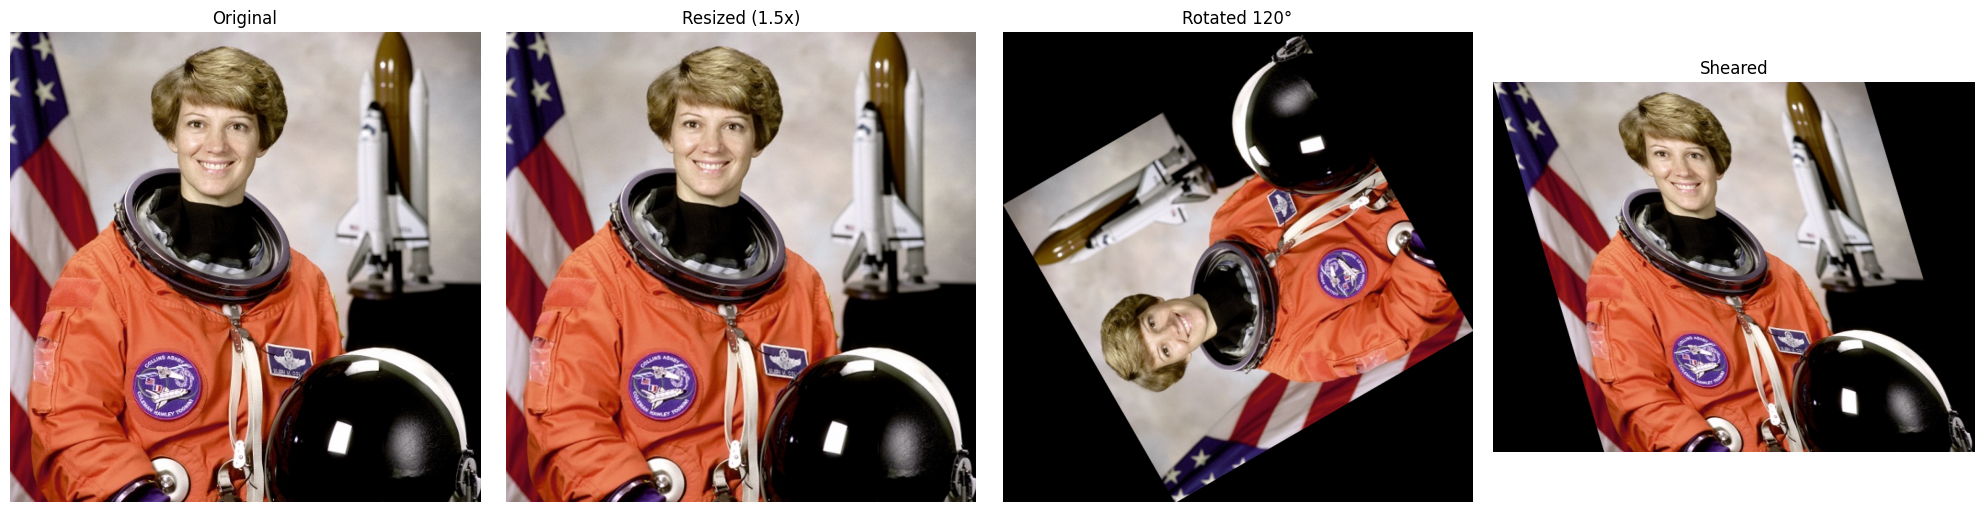

In [5]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
titles = ['Original', 'Resized (1.5x)', 'Rotated 120°', 'Sheared']
images_t1 = [img, resized, rotated, sheared]

for ax, im, t in zip(axs, images_t1, titles):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(t)
    ax.axis('off')

plt.tight_layout()
plt.savefig('images/task1_summary.jpg')
plt.show()

## Task 2 — Intensity Transformations

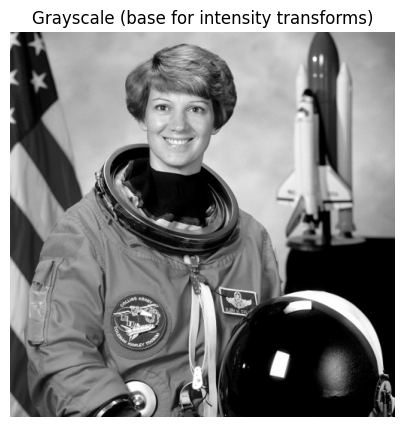

In [6]:
# Work in grayscale for intensity transformations
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
show(gray, 'Grayscale (base for intensity transforms)')

### 2.1 Create a Negative Image

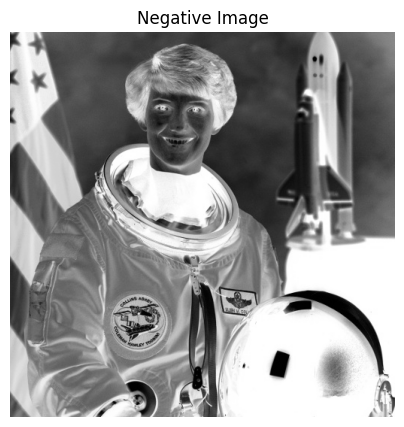

In [7]:
# Negative transformation: s = (L-1) - r, where L = 256 for 8-bit images
negative = 255 - gray

cv2.imwrite('images/task2_negative.jpg', negative)
show(negative, 'Negative Image')

### 2.2 Log Transformation

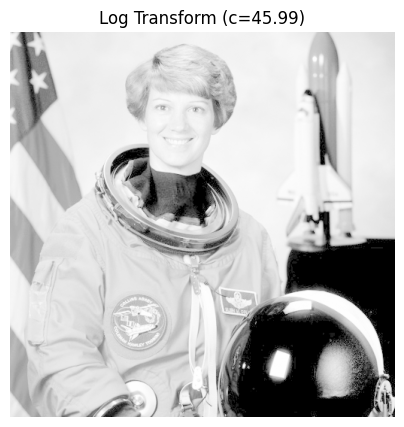

In [8]:
# Log transformation: s = c * log(1 + r)
# c is chosen so the output maps to the full 0-255 range
# (cast to float first -- 1 + uint8(255) would overflow to 0)
c = 255 / np.log(1 + float(np.max(gray)))
log_transformed = c * np.log(1 + gray.astype(np.float64))
log_transformed = np.array(log_transformed, dtype=np.uint8)

cv2.imwrite('images/task2_log.jpg', log_transformed)
show(log_transformed, f'Log Transform (c={c:.2f})')

### 2.3 Power-Law (Gamma) Transformation

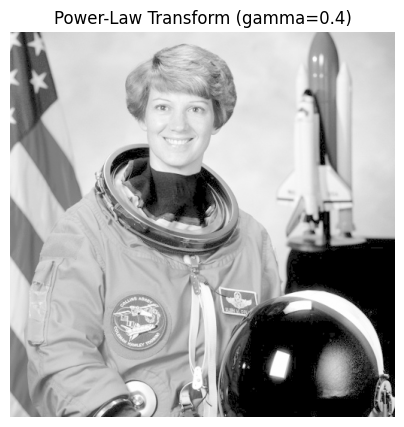

In [9]:
# Power-law transformation: s = c * r^gamma
# gamma < 1 increases contrast in the dark regions (brightens shadows)
gamma = 0.4
gamma_corrected = np.array(255 * (gray / 255.0) ** gamma, dtype=np.uint8)

cv2.imwrite('images/task2_gamma.jpg', gamma_corrected)
show(gamma_corrected, f'Power-Law Transform (gamma={gamma})')

### Task 2 — Summary

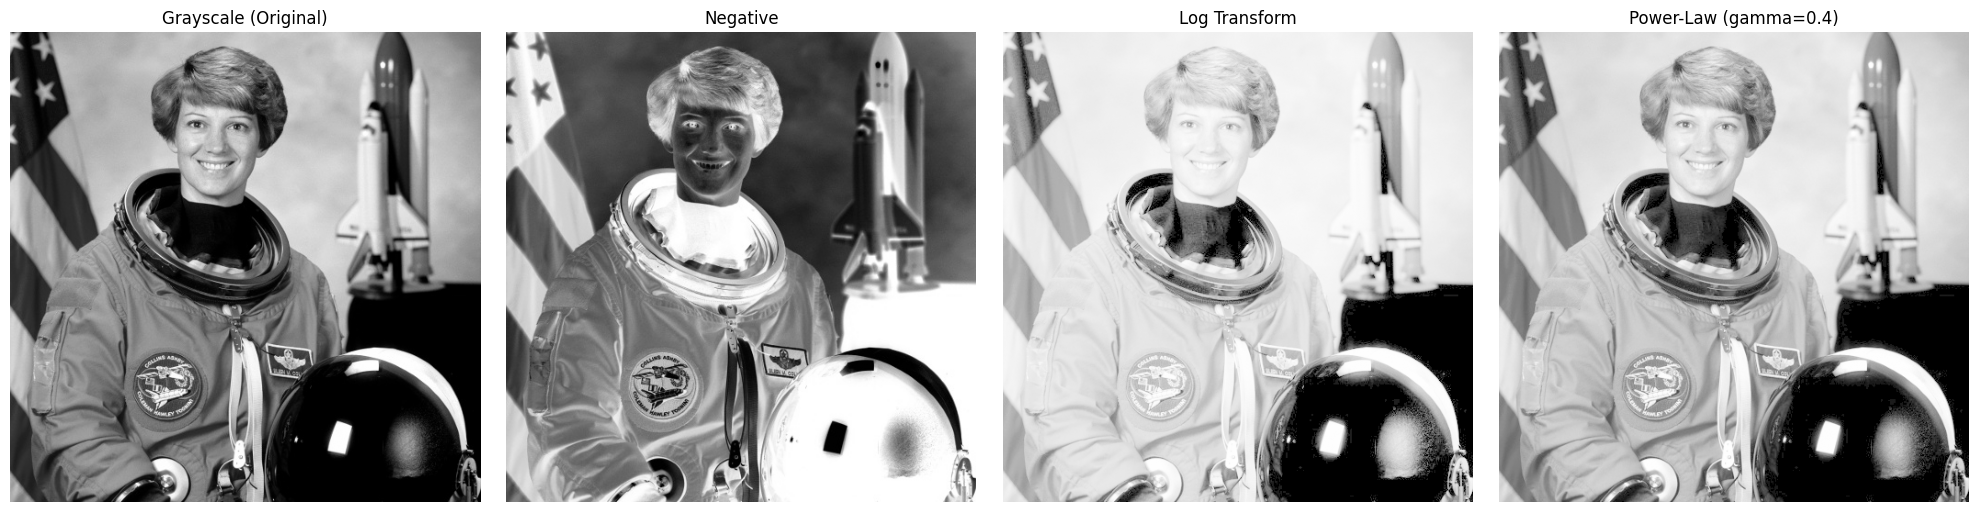

In [10]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
titles2 = ['Grayscale (Original)', 'Negative', 'Log Transform', f'Power-Law (gamma={gamma})']
images_t2 = [gray, negative, log_transformed, gamma_corrected]

for ax, im, t in zip(axs, images_t2, titles2):
    ax.imshow(im, cmap='gray')
    ax.set_title(t)
    ax.axis('off')

plt.tight_layout()
plt.savefig('images/task2_summary.jpg')
plt.show()